# Homework 3: Bayesian Models and Monte Carlo

BEE 4850/5850, Spring 2025

**Name**: Liying Ma

**ID**: Lm698

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to quantify uncertainties for a simple model
    using Bayesian statistics and rejection sampling.
-   Problem 2 asks you to use Monte Carlo simulation to calculate annual
    expected flooding damages.
-   Problem 3 (only required for students in BEE 5850) asks you to
    conduct cost-benefit analyses of housing elevation levels under
    future flooding uncertainty using Monte Carlo simulations.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4850/HW/hw03-LM698`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

## Problems

### Scoring

-   Problem 1 is worth 13 points.
-   Problem 2 is worth 7 points.
-   Problem 3 is worth 5 points.

### Problem 1

Consider the class-cheating testing procedure from [Homework
1](https://viveks.me/simulation-data-analysis/hw/hw01.html). As a
reminder, the procedure is as follows:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

Suppose that, after conducting the procedure on your class of 100
students, you get 40 “Yes, I cheated” responses. You are skeptical that
your class is broadly engaged in cheating and have a prior belief that
the probability of cheating $\theta$ is unlikely to be high. We’ll
express this prior using a beta distribution, \$(3, 40), which is shown
below. You would like to understand the range of cheating propensity
which is consistent with your prior beliefs and the outcomes from the
detection procedure.

**In this problem**:

-   Construct a Bayesian probability model (based on the data-generating
    process from Homework 1 and our prior on the cheating probability)
    for the “Yes, I cheated” counts. You can compute the likelihood
    based on the combination of the fair coin flip and the “true”
    cheating probability $\theta$.
-   Plot the posterior $p(\theta | y)$ using a grid approximation
    (looping over values of $\theta$).
-   Use rejection sampling to draw 1,000 samples from the posterior and
    plot the distribution of samples. How well are you capturing the
    posterior you obtained from the grid approximation? Would you prefer
    to have more samples?
-   Report the expected value of $\theta$ and its 90% credible interval.
    What conclusions can you draw about cheating probability and whether
    your belief in your class was warranted? How much uncertainty exists
    as a result of this privacy-protecting procedure?
-   Repeat the analysis with a less constrained prior of your choosing.
    How does that change your inferences and conclusions? What does this
    tell you about the effectiveness of the procedure?

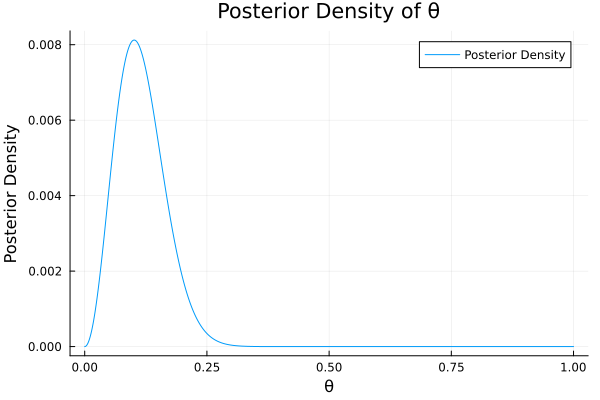

In [4]:
# Define the likelihood function
function likelihood(θ, n, y)
    p_yes = (1/2) * θ + (1/4)  # P(Y=1|θ)
    return pdf(Binomial(n, p_yes), y)
end

# Define the prior function
function prior(θ)
    return pdf(Beta(3, 40), θ)
end

# Define the posterior function
function posterior(θ, y, n)
    return likelihood(θ, n, y) * prior(θ)
end

# Define the grid approximation function
function grid_approximation(y, n; grid_size=1000)
    θ_grid = range(0, 1, length=grid_size)
    posterior_values = [posterior(θ, y, n) for θ in θ_grid]
    posterior_values ./= sum(posterior_values)
    return θ_grid, posterior_values
end

# Given data
y = 40  # Number of "Yes, I cheated" responses
n = 100  # Total number of students

# Compute the posterior using grid approximation
θ_grid, posterior_values = grid_approximation(y, n)

# Plot the posterior density vs. θ
plot(θ_grid, posterior_values, xlabel="θ", ylabel="Posterior Density", label="Posterior Density", title="Posterior Density of θ", legend=:topright)

In [5]:
M= maximum(posterior_values)

0.008122705703798194

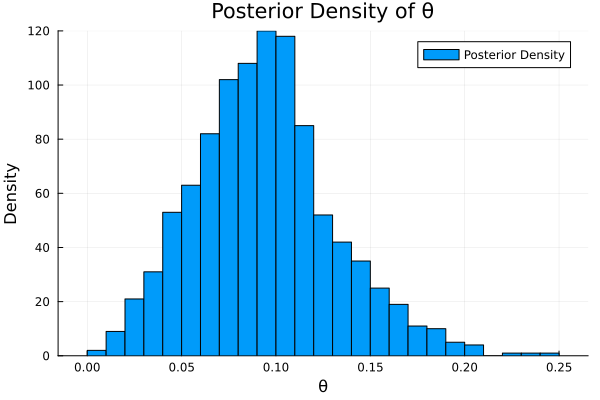

In [6]:
# Define rejection sampling function
Random.seed!(2)
function rejection_sampling(y, n, n_samples)
    samples = Float64[]
    prior_dist = Beta(3, 40)
    M = 0.0081
    
    while length(samples) < n_samples
        θ = rand(prior_dist) 
        u = rand() 
        if u < posterior(θ, y, n) / (M * prior(θ))
            push!(samples, θ)
        end
    end
    return samples
end

# Draw 1,000 samples
n_samples = 1000
samples = rejection_sampling(y,n, n_samples)

# Plot the posterior samples
histogram(samples, bins=30, xlabel="θ", ylabel="Density", label="Posterior Density", title="Posterior Density of θ")

The plot shows a clear peak around 0.09-0.105, which aligns well with the posterior distribution obtained from the grid approximation. This indicates that the rejection sampling method effectively captures the overall shape and key features of the posterior. However, the histogram still exhibits some variability due to the limited number of samples. Increasing the sample size (e.g., to 10,000 samples) would help provide a smoother, more precise representation of the posterior distribution.

In [7]:
# Compute expected value
θ_mean = mean(samples)

# Compute 90% CI
θ_CI = quantile(samples, [0.05, 0.95])

# Results
println("Expected value of θ (posterior mean): ", round(θ_mean, digits=4))
println("90% credible interval: [", round(θ_CI[1], digits=4), ", ", round(θ_CI[2], digits=4), "]")

Expected value of θ (posterior mean): 0.094
90% credible interval: [0.0375, 0.1612]


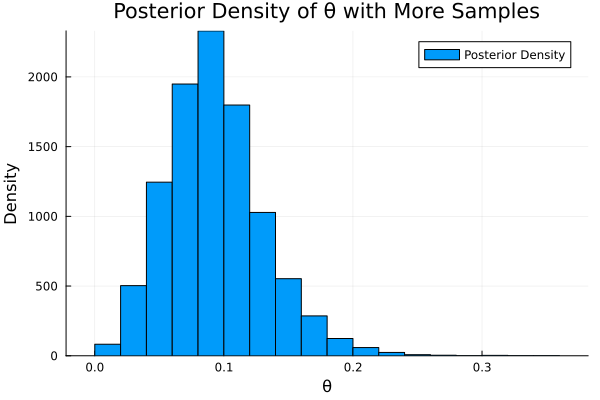

In [8]:
# Draw more samples
Random.seed!(2)
function rejection_sampling(y, n, n_samples)
    samples = Float64[]
    prior_dist = Beta(3, 40)
    M = 0.008

    while length(samples) < n_samples
        θ = rand(prior_dist)
        u = rand()
        if u < posterior(θ, y, n) / (M * prior(θ))
            push!(samples, θ)
        end
    end
    return samples
end

n_samples = 10000
samples_more = rejection_sampling(y,n, n_samples)

# Plot the posterior samples
histogram(samples_more, bins=30, xlabel="θ", ylabel="Density", label="Posterior Density", title="Posterior Density of θ with More Samples")

In [9]:
# Compute expected value
θ_mean = mean(samples_more)

# Compute 90% CI
θ_CI = quantile(samples_more, [0.05, 0.95])

# Results
println("Expected value of θ (posterior mean): ", round(θ_mean, digits=4))
println("90% credible interval: [", round(θ_CI[1], digits=4), ", ", round(θ_CI[2], digits=4), "]")

Expected value of θ (posterior mean): 0.0934
90% credible interval: [0.0377, 0.1604]


The posterior mean (~9.4%) suggests that the true cheating probability is relatively low, despite 40% of students responding "Yes, I cheated."
The results are consistent with the prior belief that the cheating rate is not high (Beta(3,40)), indicating that the randomized response method introduced noise but did not significantly alter the prior expectation.
The credible interval (3.8% to 16.1%) indicates that while there is some uncertainty, high cheating rates (e.g., above 20-30%) are highly unlikely based on the data.

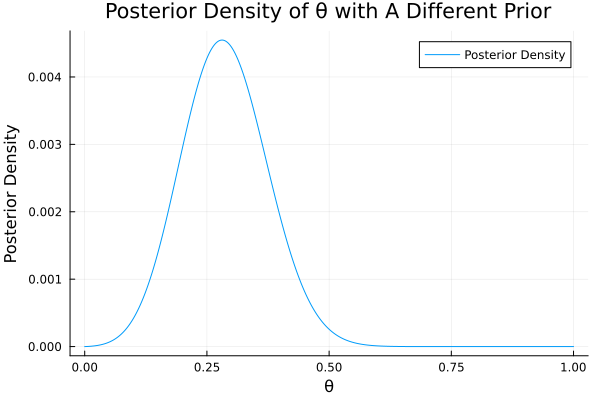

In [ ]:
# Try a different prior
# Chose Beta(2,5), becuase allows for more flexibility in the possible values of θ, compared to Beta(3,40). 
# By using Beta(2,5), we reduce this restriction and allow the posterior to be more influenced by the observed data. 
# This prior still reflects some skepticism about high values of θ, but it is more flexible and ensures 
# that our conclusions are not overly dependent on a strict prior assumption.

# Define new prior function
function prior_new(θ)
    return pdf(Beta(2,5), θ)
end

# Define the posterior function
function posterior(θ, y, n)
    return likelihood(θ, n, y) * prior_new(θ)
end

# Define the grid approximation function
function grid_approximation(y, n; grid_size=1000)
    θ_grid = range(0, 1, length=grid_size)
    posterior_values = [posterior(θ, y, n) for θ in θ_grid]
    posterior_values ./= sum(posterior_values)
    return θ_grid, posterior_values
end

# Given data
y = 40  # Number of "Yes, I cheated" responses
n = 100  # Total number of students

# Compute the posterior using grid approximation
θ_grid, posterior_values = grid_approximation(y, n)

# Plot the posterior density vs. θ
plot(θ_grid, posterior_values, xlabel="θ", ylabel="Posterior Density", label="Posterior Density", title="Posterior Density of θ with a Different Prior", legend=:topright)

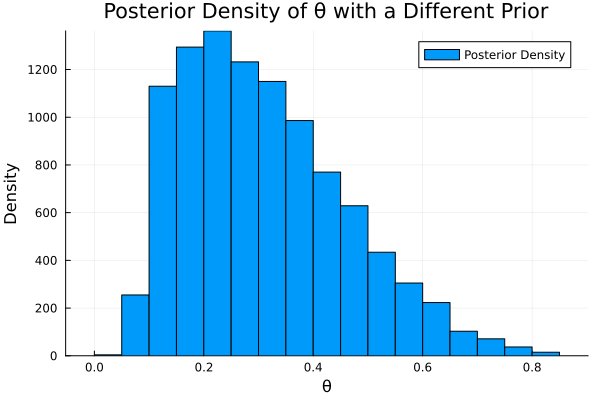

In [ ]:
# Define rejection sampling function
Random.seed!(1)
function rejection_sampling(y, n, n_samples)
    samples = Float64[]
    prior_dist = Beta(2,5)
    M = maximum(posterior_values)

    while length(samples) < n_samples
        θ = rand(prior_dist)  
        u = rand() 
        if u < posterior(θ, y, n) / (M * prior(θ))
            push!(samples, θ)
        end
    end
    return samples
end

n_samples = 10000
samples = rejection_sampling(y,n, n_samples)

# Plot the posterior samples
histogram(samples, bins=30, xlabel="θ", ylabel="Density", label="Posterior Density", title="Posterior Density of θ with a Different Prior")

In [12]:
# Compute expected value
θ_mean = mean(samples)

# Compute 90% CI
θ_CI = quantile(samples, [0.05, 0.95])

# Results
println("Expected value of θ (posterior mean): ", round(θ_mean, digits=4))
println("90% credible interval: [", round(θ_CI[1], digits=4), ", ", round(θ_CI[2], digits=4), "]")

Expected value of θ (posterior mean): 0.3105
90% credible interval: [0.1125, 0.5903]


With Beta(3,40), the posterior mean is 0.094 with a 90% credible interval of [0.0375, 0.1612], suggesting a low cheating probability. However, with Beta(2,5), the posterior mean jumps to 0.3122, with a much wider credible interval of [0.1136, 0.5935], allowing for significantly higher values of θ.

This change indicates that the data alone is not strong enough to override prior assumptions, making the choice of prior critical in Bayesian inference. The Beta(3,40) prior is highly informative, restricting θ to low values, while Beta(2,5) is more flexible, allowing for greater uncertainty. The fact that different priors lead to different conclusions suggests that the randomized response method may not provide conclusive evidence on its own, and additional data or external information may be needed for a more reliable estimate.

### Problem 2

You have been asked by a client to assess the risks of flooding to their
home (which is valued at \$400,000 and only floods when the stream water
levels exceed 1.5m). They would like to know the probability
distribution of annual flood damages to their home if they do not take
any preventative floodproofing measures. After some hydrologic analysis,
you have developed a 40-year record of annual maximum water levels (in
m) at the nearby stream.

You also have a depth-damage function for the fraction of the home’s
value which is damaged at varying flood depths:

$$d(h) = \mathbb{I}[h > 0] \frac{1}{1+\exp(-k(x-x_0))},$$

where $k=1.25$ and $x_0=2$[1]. The graph of this function is given in
the figure below.

[1] As a reminder, the indicator function $\mathbb{I}[h > 0]$ is $0$
when the condition is not satisfied (in this case, when $h=0$) and $1$
when it is satisfied.

**In this problem**:

-   Fit a log-normal distribution to the water depth data by maximizing
    likelihood.
-   Use 10,000 samples from this distribution to estimate the expected
    damages from an annual maximum flood event using Monte Carlo
    simulation. Report your estimate as well as its standard error.
    Would you want to use more samples? Why or why not?


In [18]:
file_path = "/Users/liyingma/BEE4850/HW/hw03-LM698/data/water_depths.csv"  
data = CSV.read(file_path, DataFrame)
water_depths = data.depths

# Define the log-likelihood function
function log_likelihood(params, data)
    μ, σ = params
    dist = LogNormal(μ, σ)
    return sum(logpdf.(dist, data))
end

initial_params = [mean(log.(water_depths)), std(log.(water_depths))]

neg_log_likelihood(params) = -log_likelihood(params, water_depths)
result = optimize(neg_log_likelihood, initial_params)

μ_opt, σ_opt = result.minimizer

println("Optimized μ: ", μ_opt)
println("Optimized σ: ", σ_opt)


Optimized μ: 0.140574960325204
Optimized σ: 0.2496345679258946


In [20]:
# Monte Carlo samples
num_samples = 10_000

# Generate random samples from the fitted log-normal distribution
Random.seed!(1)
mc_samples = rand(LogNormal(μ_opt, σ_opt), num_samples)

10000-element Vector{Float64}:
 1.130833497158094
 1.3142286691085143
 0.9409707051868615
 2.125325421926467
 1.539361617448743
 1.2304356434727588
 1.7814344339803854
 0.936478810929484
 0.8871580843188056
 1.0601514496274458
 ⋮
 1.1222386494635352
 1.1218075061308106
 1.7946868630356434
 0.9175804317786257
 0.8636140638209805
 1.2719087794962753
 1.12654619665548
 0.9700382289907468
 1.2788790061954378

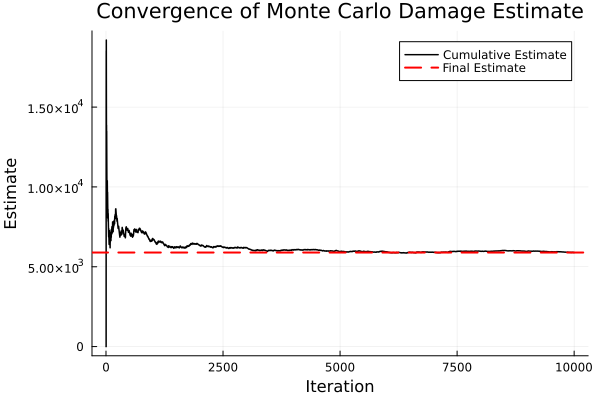

In [21]:
# Damage function
function damage_function(h, k=1.25, x0=2)
    if h > 0
        return 1 / (1 + exp(-k * (h - x0)))
    else
        return 0
    end
end

# Define house value
house_value = 400_000  # in dollars

# Define water depth relative to house's elevation
depth = mc_samples .- 1.5

# Compute damages for each sample
damages = [damage_function(h) * house_value for h in depth]

# Compute cumulative mean estimate over iterations
cumulative_mean = cumsum(damages) ./ (1:num_samples)

# Final expected damage estimate
final_estimate = round(cumulative_mean[end],digits=2)

plot(1:num_samples, cumulative_mean, label="Cumulative Estimate", color=:black, lw=1.5)
hline!([final_estimate], linestyle=:dash, linewidth=2, color=:red, label="Final Estimate")
xlabel!("Iteration")
ylabel!("Estimate")
title!("Convergence of Monte Carlo Damage Estimate")


In [22]:
# Compute expected damage and standard error
expected_damage = mean(damages)
std_error = std(damages) / sqrt(num_samples)

# Results
println("Estimated Expected Annual Damage: \$", round(expected_damage, digits=2))
println("Standard Error: \$", round(std_error, digits=2))

Estimated Expected Annual Damage: $5892.52
Standard Error: $147.9


From the simulation, the estimated expected annual damage is $5892.52, with a standard error of $147.9. However, based on the convergence plot, we can see that the cumulative estimate has already stabilized after several thousand iterations, meaning additional samples would likely provide only marginal improvements. Furthermore, since the standard error is already low (~2.5% of the estimate), using more samples is not strictly necessary unless further precision is required for decision-making.